# Activity 4 — Data Cleaning & Outlier Detection

Dataset supplied by the lab.

We will:
1. handle missing Age and Salary,
2. encode Department,
3. visualize Salary outliers with a boxplot,
4. inspect Zara's salary.

### Important distinction
An outlier is not automatically an error. Zara's salary can be statistically unusual while still being a valid value.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Name": ["Ahsan", "Hira", "Bilal", "Zara", "Salman", "Mahnoor"],
    "Age": [25, 27, 35, 29, None, 40],
    "Salary": [50000, None, 75000, 2000000, 60000, 90000],
    "Department": ["IT", "Finance", "IT", "HR", "Finance", "IT"]
}

df = pd.DataFrame(data)

print(df)
print("\nMissing values:")
print(df.isna().sum())

      Name   Age     Salary Department
0    Ahsan  25.0    50000.0         IT
1     Hira  27.0        NaN    Finance
2    Bilal  35.0    75000.0         IT
3     Zara  29.0  2000000.0         HR
4   Salman   NaN    60000.0    Finance
5  Mahnoor  40.0    90000.0         IT

Missing values:
Name          0
Age           1
Salary        1
Department    0
dtype: int64


## Task 1 — Handle missing values

`Age` and `Salary` are numerical columns.

We use the median because salary can contain extreme values such as Zara's 2,000,000 salary. Median is less influenced by an extreme value than mean.

In [2]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

print("After handling missing values:")
print(df)

print("\nRemaining missing values:")
print(df.isna().sum())

After handling missing values:
      Name   Age     Salary Department
0    Ahsan  25.0    50000.0         IT
1     Hira  27.0    75000.0    Finance
2    Bilal  35.0    75000.0         IT
3     Zara  29.0  2000000.0         HR
4   Salman  29.0    60000.0    Finance
5  Mahnoor  40.0    90000.0         IT

Remaining missing values:
Name          0
Age           0
Salary        0
Department    0
dtype: int64


## Task 2 — Encode Department

`get_dummies()` performs one-hot encoding. Each department gets a separate binary column.

In [3]:
department_encoded = pd.get_dummies(
    df["Department"],
    prefix="Department"
)

df_encoded = pd.concat([df, department_encoded], axis=1)

print(df_encoded)

      Name   Age     Salary Department  Department_Finance  Department_HR  \
0    Ahsan  25.0    50000.0         IT               False          False   
1     Hira  27.0    75000.0    Finance                True          False   
2    Bilal  35.0    75000.0         IT               False          False   
3     Zara  29.0  2000000.0         HR               False           True   
4   Salman  29.0    60000.0    Finance                True          False   
5  Mahnoor  40.0    90000.0         IT               False          False   

   Department_IT  
0           True  
1          False  
2           True  
3          False  
4          False  
5           True  


## Task 3 — Detect salary outliers using a boxplot

A boxplot provides a visual way to see unusually high or low salary values.

We also calculate the IQR boundaries so we can identify which rows lie beyond the whiskers.

C:\Users\PMLS\AppData\Local\Temp\ipykernel_12988\3277307815.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Salary"], vert=True)


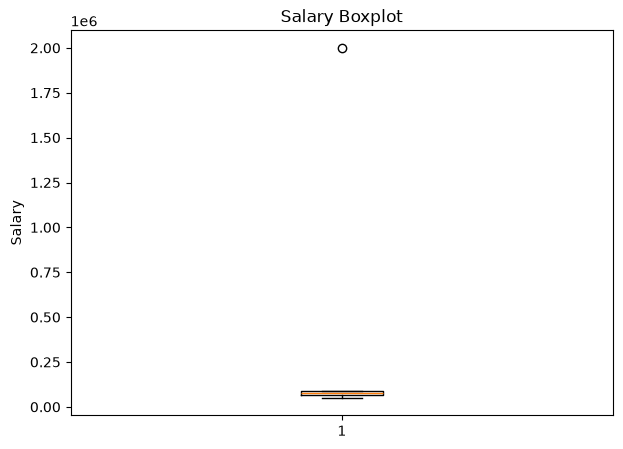

Q1: 63750.0
Q3: 86250.0
IQR: 22500.0
Lower boundary: 30000.0
Upper boundary: 120000.0

Potential salary outliers:
   Name     Salary
3  Zara  2000000.0


In [4]:
plt.figure(figsize=(7, 5))
plt.boxplot(df["Salary"], vert=True)
plt.ylabel("Salary")
plt.title("Salary Boxplot")
plt.show()

Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

salary_outliers = df[
    (df["Salary"] < lower) |
    (df["Salary"] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower boundary:", lower)
print("Upper boundary:", upper)

print("\nPotential salary outliers:")
print(salary_outliers[["Name", "Salary"]])

## Task 4 — Should Zara's salary be treated as an outlier?

Based on the boxplot/IQR calculation, Zara's salary is statistically unusual if it falls above the upper IQR boundary.

But **statistical outlier ≠ incorrect data**.

If Zara's salary is a genuine value, we normally should not simply delete it. Whether it should be removed depends on the purpose of the analysis and whether the value is a data-entry error.

For this lab, the correct conclusion is: **Zara's salary is a statistical outlier, but that alone is not enough reason to delete it.**

In [5]:
zara_salary = df.loc[df["Name"] == "Zara", "Salary"].iloc[0]

print("Zara's salary:", zara_salary)
print("Upper IQR boundary:", upper)

if zara_salary > upper:
    print("Zara's salary is statistically identified as an outlier.")
else:
    print("Zara's salary is not identified as an outlier.")

Zara's salary: 2000000.0
Upper IQR boundary: 120000.0
Zara's salary is statistically identified as an outlier.
